### Divisão do dataset em treino/validação/teste

In [1]:
import os
import random
import shutil
from pathlib import Path

random.seed(42)

BASE = Path.cwd()  # pasta onde o script roda (reciclaAI/)
RAW = BASE / "raw_trashnet"
OUT = BASE / "reciclaAI_dataset"

CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# proporções
train_frac = 0.70
val_frac = 0.15
test_frac = 0.15

assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

def is_image_file(fn):
    return fn.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}

# cria pastas
for split in ["train", "val", "test"]:
    for c in CLASSES:
        (OUT / split / c).mkdir(parents=True, exist_ok=True)

summary = {}

for c in CLASSES:
    src_dir = RAW / c
    if not src_dir.exists():
        print(f"[AVISO] pasta {src_dir} não encontrada - classe {c} pulada")
        continue

    imgs = [p for p in src_dir.iterdir() if p.is_file() and is_image_file(p)]
    random.shuffle(imgs)
    n = len(imgs)
    n_train = int(train_frac * n)
    n_val = int(val_frac * n)
    # garantimos que todas somem
    n_test = n - n_train - n_val

    train_imgs = imgs[:n_train]
    val_imgs = imgs[n_train:n_train + n_val]
    test_imgs = imgs[n_train + n_val:]

    for p in train_imgs:
        shutil.copy(p, OUT / "train" / c / p.name)
    for p in val_imgs:
        shutil.copy(p, OUT / "val" / c / p.name)
    for p in test_imgs:
        shutil.copy(p, OUT / "test" / c / p.name)

    summary[c] = {"total": n, "train": len(train_imgs), "val": len(val_imgs), "test": len(test_imgs)}

print("\nResumo por classe:")
total_all = 0
for c,v in summary.items():
    print(f" {c}: total={v['total']}  train={v['train']}  val={v['val']}  test={v['test']}")
    total_all += v['total']
print(f"\nTotal de imagens: {total_all}")
print(f"Dataset criado em: {OUT.resolve()}")


Resumo por classe:
 cardboard: total=403  train=282  val=60  test=61
 glass: total=501  train=350  val=75  test=76
 metal: total=410  train=287  val=61  test=62
 paper: total=594  train=415  val=89  test=90
 plastic: total=482  train=337  val=72  test=73
 trash: total=137  train=95  val=20  test=22

Total de imagens: 2527
Dataset criado em: C:\Users\Aluno\Desktop\Modelo_v1\reciclaAI_dataset


### Treino do modelo

Found 1766 images belonging to 6 classes.
Found 377 images belonging to 6 classes.
Found 384 images belonging to 6 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

...

56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 432ms/step - accuracy: 0.7135 - loss: 0.7506 - val_accuracy: 0.8143 - val_loss: 0.5561
Epoch 12/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.7049 - loss: 0.7580

56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 441ms/step - accuracy: 0.7106 - loss: 0.7380 - val_accuracy: 0.8090 - val_loss: 0.5444
Epoch 13/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.7443 - loss: 0.7115

56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 429ms/step - accuracy: 0.7480 - loss: 0.6903 - val_accuracy: 0.8090 - val_loss: 0.5332
Epoch 14/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.7593 - loss: 0.6591

56/56 ━━━━━━━━━━━━━━━━━━━━ 24s 429ms/step - accuracy: 0.7486 - loss: 0.6797 - val_accuracy: 0.8143 - val_loss: 0.5282
Epoch 15/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.7417 - loss: 0.6677

56/56 ━━━━━━━━━━━━━━━━━━━━ 25s 447ms/step - accuracy: 0.7475 - loss: 0.6650 - val_accuracy: 0.8223 - val_loss: 0.5128
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 291ms/step - accuracy: 0.7839 - loss: 0.6053

 Acurácia no conjunto de teste: 0.7839
 Loss no conjunto de teste: 0.6053


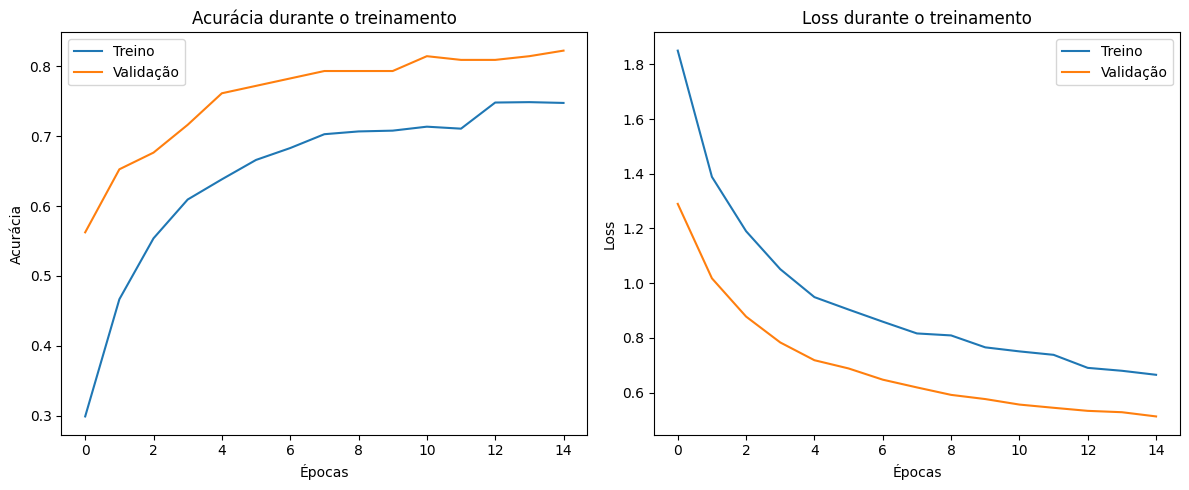


 Modelo salvo como reciclaAI_model_final


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os


# Definições gerais
DATASET_DIR = "reciclaAI_dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-4  # taxa de aprendizado

# classes 
CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
NUM_CLASSES = len(CLASSES)


# Preparação do dataset
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(DATASET_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


# Construção do modelo baseado no MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # congela pesos do modelo base

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=LR),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()



callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint("reciclaAI_best_model.h5", save_best_only=True)
]


# Treinamento
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


# Avaliação
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n Acurácia no conjunto de teste: {test_acc:.4f}")
print(f" Loss no conjunto de teste: {test_loss:.4f}")


# Gráficos
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# SALVAR MODELO FINAL
model.save("reciclaAI_model_final.h5")
print("\n Modelo salvo como reciclaAI_model_final")
